# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [78]:
data = keras.utils.get_file('auto-mpg.data', 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data')

Importelo usando pandas.

In [79]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [80]:
dataset = pd.read_csv(data, names=column_names,
                          na_values="?", comment='\t',
                          sep=r"\s+", skipinitialspace=True)

dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


### Limpia los datos

Trata los missings y variables categóricas

In [81]:
dataset = dataset.dropna()
dataset = dataset.drop('Car name', axis=1)

### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [82]:
train_dataset = dataset.sample(frac=0.8, random_state=42)
test_dataset = dataset.drop(train_dataset.index)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 314
Test set size: 78


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

Tambien revise las estadisticas generales:

### 📋 Muestra

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


### 📊 Info → `392` filas × `8` columnas

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Origin        392 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 35.7 KB
None


#### Uniques

...

### ⚠️ Null & NaN

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin


### 📦 Describe

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,392.000,392.000,392.000,392.000,392.000,392.000,392.000,392.000
mean,23.446,5.472,194.412,104.469,2977.584,15.541,75.980,1.577
std,7.805,1.706,104.644,38.491,849.403,2.759,3.684,0.806
min,9.000,3.000,68.000,46.000,1613.000,8.000,70.000,1.000
25%,17.000,4.000,105.000,75.000,2225.250,13.775,73.000,1.000
50%,22.750,4.000,151.000,93.500,2803.500,15.500,76.000,1.000
75%,29.000,8.000,275.750,126.000,3614.750,17.025,79.000,2.000
max,46.600,8.000,455.000,230.000,5140.000,24.800,82.000,3.000


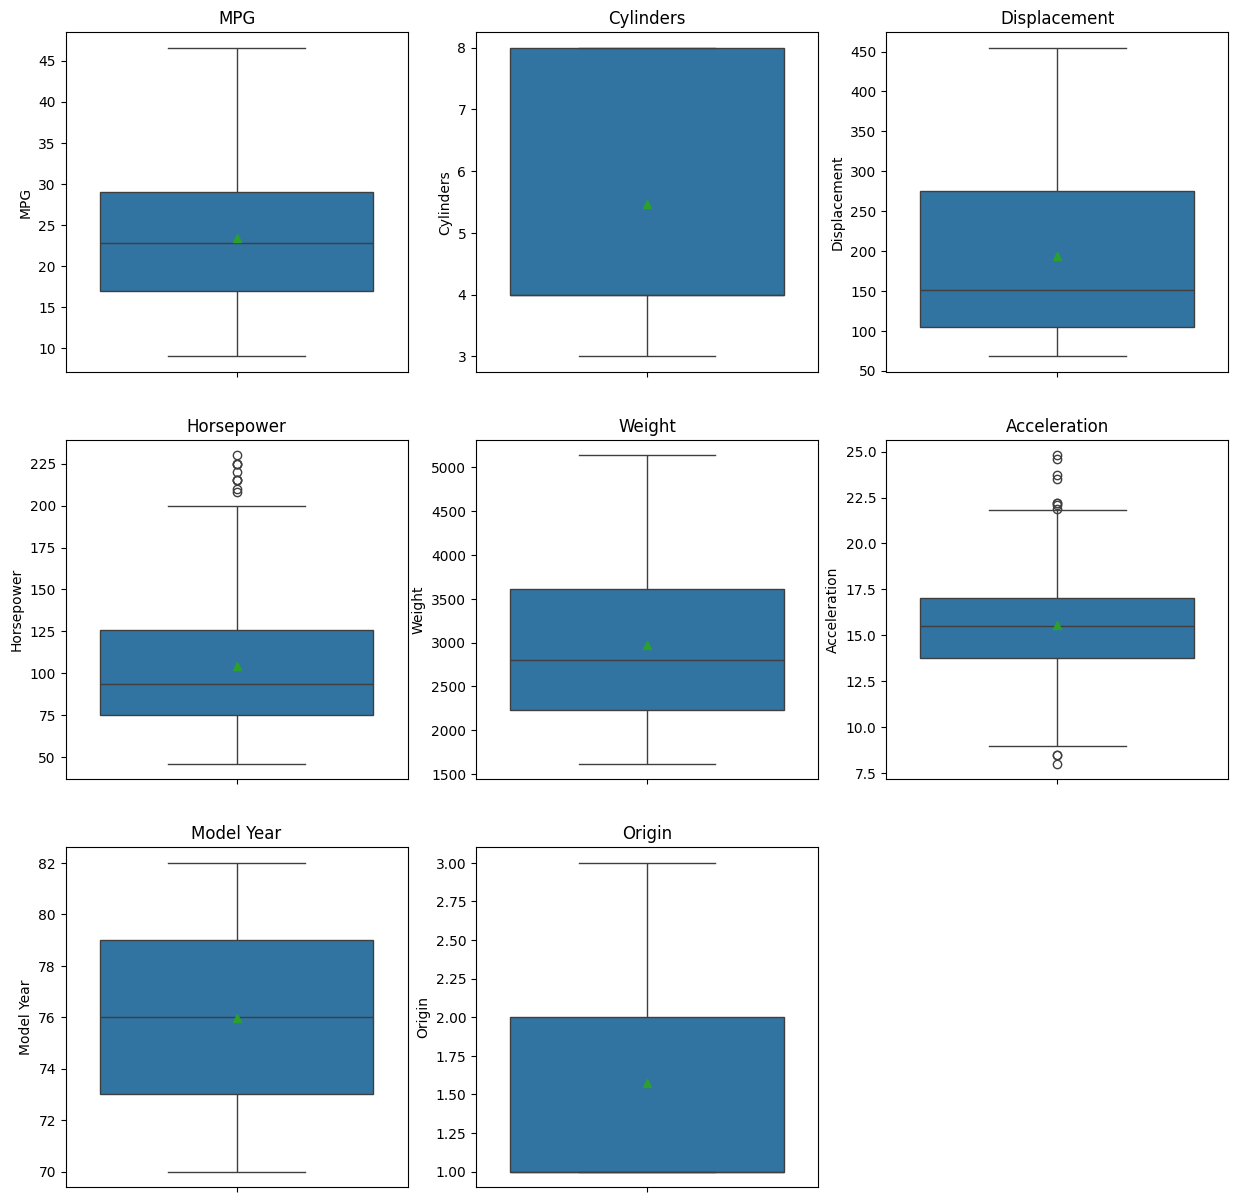

### 📈 Comparación

### (target: MPG)

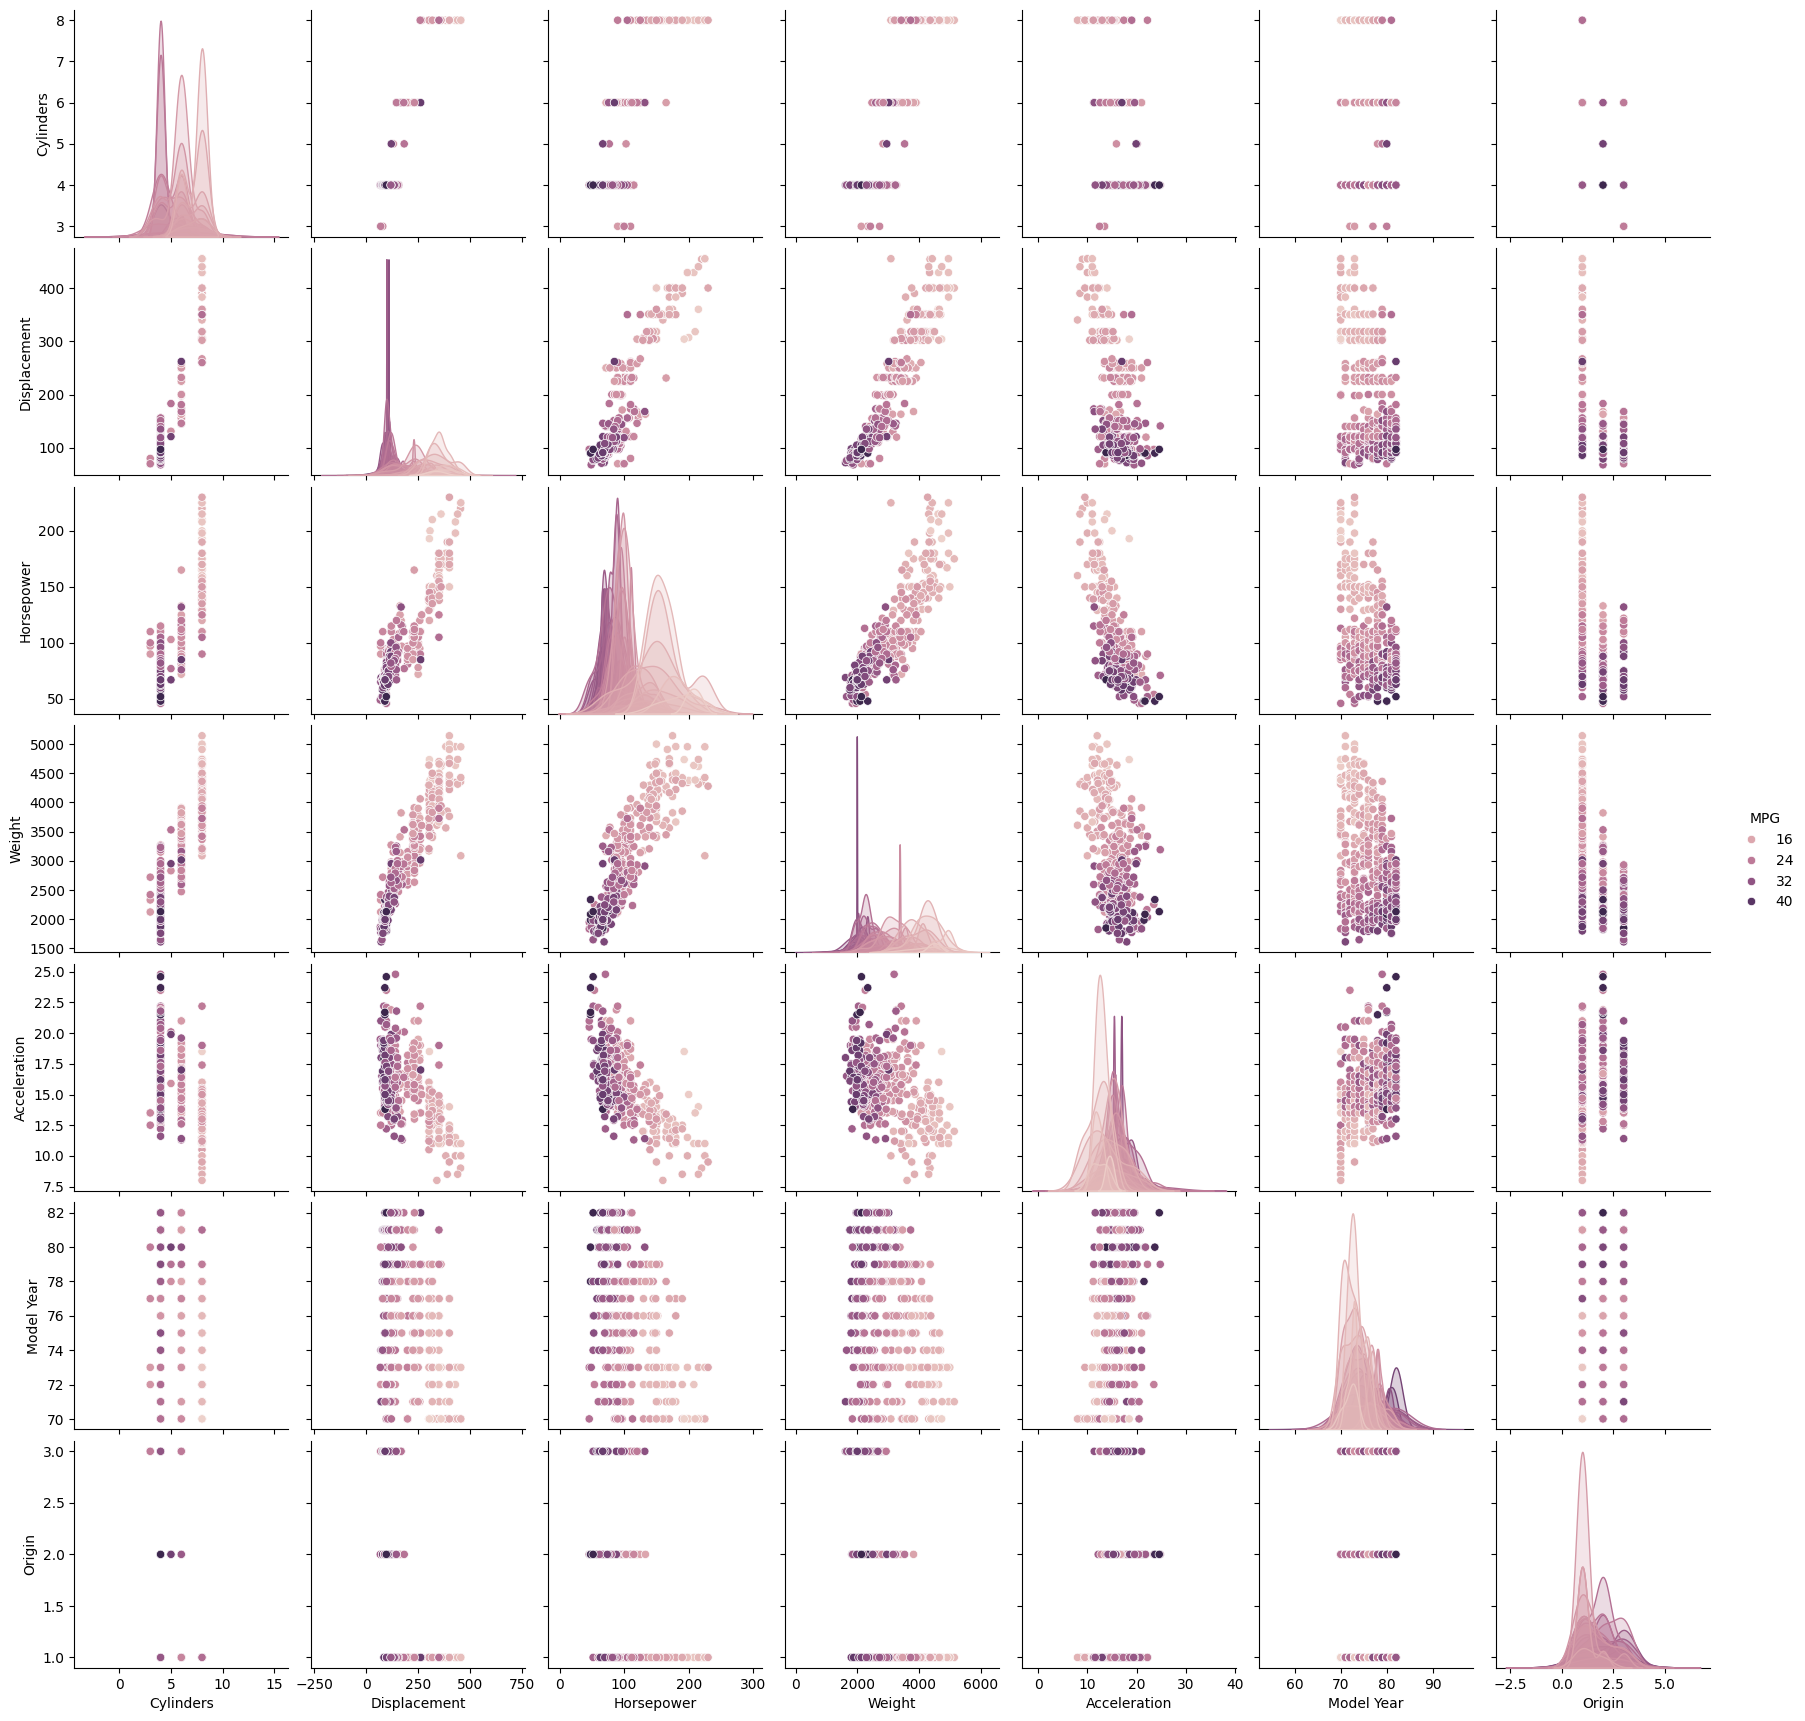

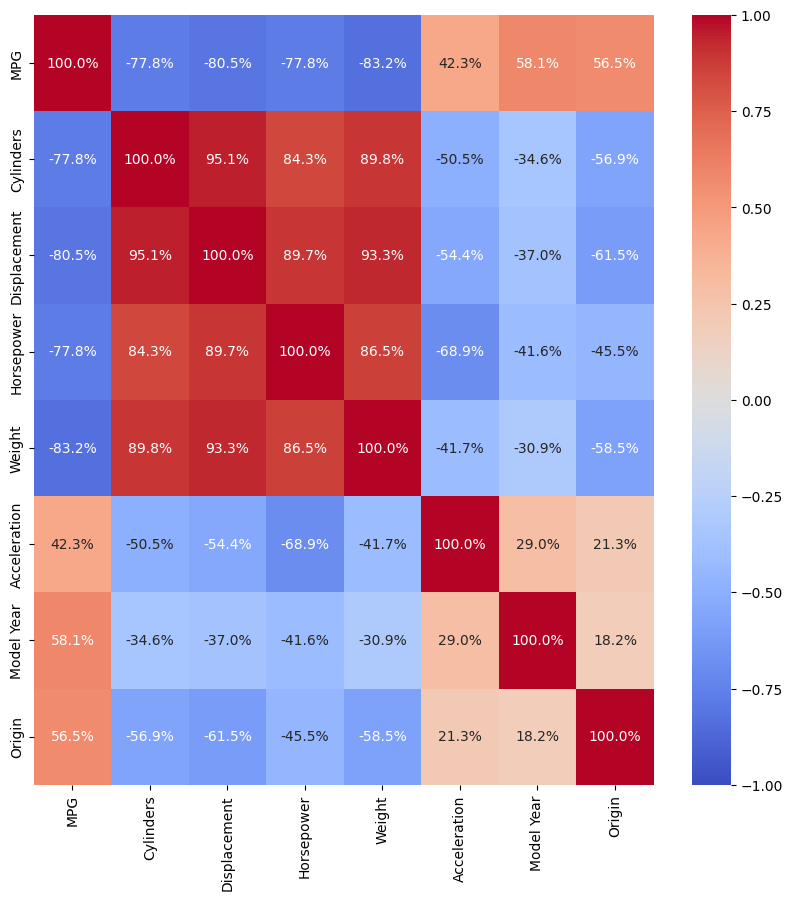

In [83]:
from src.mi_eda import eda

eda(dataset, dataset['MPG'])

### Separa las features del target

Separe el target de las features.

In [84]:
train_features = train_dataset.drop('MPG', axis=1)
train_target = train_dataset['MPG']

In [99]:
test_features = test_dataset.drop('MPG', axis=1)
test_target = test_dataset['MPG']

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [86]:
from sklearn.preprocessing import StandardScaler

norm_train_data = StandardScaler().fit_transform(train_features)
norm_test_data = StandardScaler().fit_transform(test_features)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [87]:
model = keras.Sequential([
    # Capa de entrada: Dense con input_shape igual al número de columnas
    keras.layers.Dense(64, activation='relu', input_shape=[norm_train_data.shape[1]]),
    
    # Capa oculta
    keras.layers.Dense(64, activation='relu'),
    
    # Capa de salida: 1 neurona para predecir el valor continuo (MPG)
    keras.layers.Dense(1)
])

c:\Users\Varushet\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='mse',
    optimizer = tf.keras.optimizers.RMSprop(0.001)
    metrics = ['mae', 'mse']
)

### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [89]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [90]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("callback_model.keras")

history = model.fit(
  norm_train_data, train_target,
  epochs=1000, validation_split=0.2, verbose=0,
  callbacks=[checkpoint_cb]
)

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

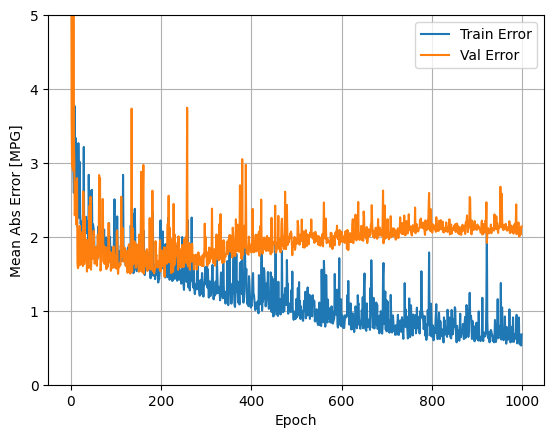

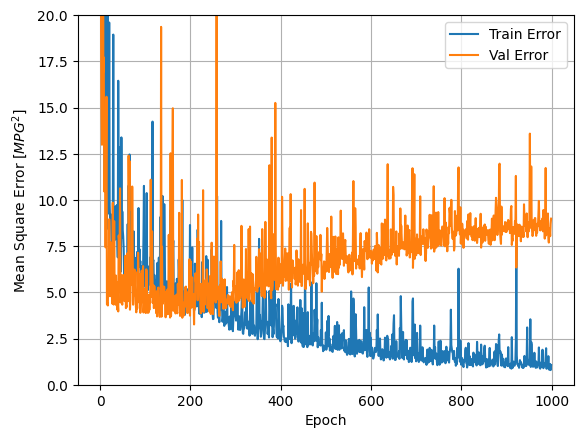

In [91]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [MPG]')
  plt.plot(hist['epoch'], hist['mae'], label='Train Error')
  plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
  plt.ylim([0,5])
  plt.legend()
  plt.grid(True)
  plt.show()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [$MPG^2$]')
  plt.plot(hist['epoch'], hist['mse'], label='Train Error')
  plt.plot(hist['epoch'], hist['val_mse'], label = 'Val Error')
  plt.ylim([0,20])
  plt.legend()
  plt.grid(True)
  plt.show()

plot_history(history)

¿Alguna conclusión respecto a este gráfico?

El epoch causa una diferenciación temprana de las estadísticas en train y test. Quizá un valor meno, cercano a 200, sería más acertado

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [101]:
loss, mae, mse = model.evaluate(norm_test_data, test_target, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 15ms/step - loss: 13.9588 - mae: 2.6279 - mse: 13.9588
Testing set Mean Abs Error:  2.63 MPG


Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [102]:
test_predictions = model.predict(norm_test_data).flatten()

for i in range(10):
    print(f"Real: {test_target.iloc[i]:.2f}, Predicho: {test_predictions[i]:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Real: 15.00, Predicho: 13.55
Real: 14.00, Predicho: 6.08
Real: 25.00, Predicho: 23.29
Real: 24.00, Predicho: 26.52
Real: 17.00, Predicho: 15.67
Real: 13.00, Predicho: 11.26
Real: 23.00, Predicho: 26.66
Real: 28.00, Predicho: 26.81
Real: 30.00, Predicho: 26.77
Real: 31.00, Predicho: 31.84


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

Text(0.5, 1.0, 'Predicciones vs Valores Reales')

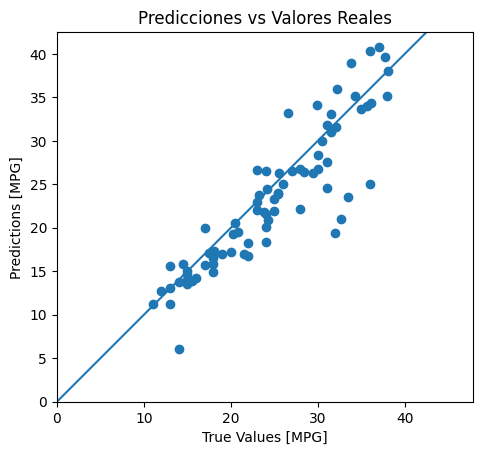

In [103]:
plt.scatter(test_target, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100]) # Línea ideal de predicción perfecta
plt.title("Predicciones vs Valores Reales")

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

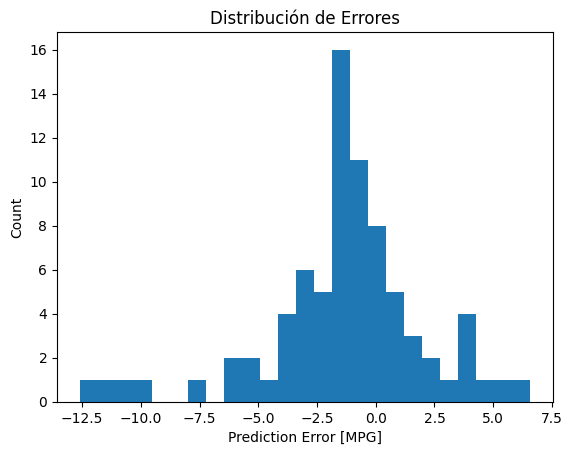

In [106]:
error = test_predictions - test_target
plt.hist(error, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")
plt.title("Distribución de Errores")
plt.show()

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [107]:
model.save('auto_mpg_model.keras')

## Conclusion